In [2]:
import os
os.chdir("/resnick/groups/GoentoroLab/LiY/illumina")
os.getcwd()

'/resnick/groups/GoentoroLab/LiY/illumina'

In [3]:
from pathlib import Path
import anndata
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
from scipy import sparse, io
import harmonypy
%matplotlib inline

/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [4]:
ROOT = Path("/resnick/groups/GoentoroLab/LiY/illumina")
MERGED = ROOT / "kb_out_v4" / "merged_unfiltered_h5ad"

paths = sorted(MERGED.glob("*.h5ad"))
print("n_files =", len(paths))
for p in paths:
    print(p.name)

adatas = {}
for p in paths:
    adatas[p.stem] = anndata.read_h5ad(p)
    print("loaded", p.stem, ":", adatas[p.stem].n_obs, "cells ×", adatas[p.stem].n_vars, "genes")

n_files = 8
Goentoro_Dec15FTC_S1_counts_unfiltered_merged.h5ad
Goentoro_Dec15PAT_S2_counts_unfiltered_merged.h5ad
Goentoro_Dec22FTC_S3_counts_unfiltered_merged.h5ad
Goentoro_Dec22PAT_S4_counts_unfiltered_merged.h5ad
Goentoro_Nov24FTC_S3_counts_unfiltered_merged.h5ad
Goentoro_Nov24PAT_S4_counts_unfiltered_merged.h5ad
Goentoro_Nov6FTC_S1_counts_unfiltered_merged.h5ad
Goentoro_Nov6PAT_S2_counts_unfiltered_merged.h5ad


/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


loaded Goentoro_Dec15FTC_S1_counts_unfiltered_merged : 794701 cells × 24254 genes


/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


loaded Goentoro_Dec15PAT_S2_counts_unfiltered_merged : 1092391 cells × 24254 genes


...

/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


loaded Goentoro_Nov24PAT_S4_counts_unfiltered_merged : 1064277 cells × 24254 genes


/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


loaded Goentoro_Nov6FTC_S1_counts_unfiltered_merged : 604364 cells × 24254 genes
loaded Goentoro_Nov6PAT_S2_counts_unfiltered_merged : 940585 cells × 24254 genes


/home/yutian/miniconda3/envs/sc_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
#Calculate total counts and total genes for each cell
for a in adatas.values():
    if "total_counts" not in a.obs or "n_genes_by_counts" not in a.obs:
        sc.pp.calculate_qc_metrics(a, inplace=True)

In [6]:
import re

RUN_ORDER = {
    "Nov6": 0,
    "Nov24": 2,
    "Dec15": 4,
    "Dec22": 6,
}

def sample_index(name):
    m_run = re.search(r"Goentoro_(Nov\d+|Dec\d+)", name)
    if not m_run:
        return float("inf")
    run = m_run.group(1)

    m_s = re.search(r"_S(\d+)", name)
    if not m_s:
        return float("inf")

    s = int(m_s.group(1))

    # normalize S within run
    if run in ("Nov24", "Dec22"):
        s -= 2   # S3,S4 → 1,2

    return RUN_ORDER[run] + s


In [7]:
adatas = dict(
    sorted(adatas.items(), key=lambda x: sample_index(x[0]))
)

In [8]:
for k in adatas:
    print(sample_index(k), k)

1 Goentoro_Nov6FTC_S1_counts_unfiltered_merged
2 Goentoro_Nov6PAT_S2_counts_unfiltered_merged
3 Goentoro_Nov24FTC_S3_counts_unfiltered_merged
4 Goentoro_Nov24PAT_S4_counts_unfiltered_merged
5 Goentoro_Dec15FTC_S1_counts_unfiltered_merged
6 Goentoro_Dec15PAT_S2_counts_unfiltered_merged
7 Goentoro_Dec22FTC_S3_counts_unfiltered_merged
8 Goentoro_Dec22PAT_S4_counts_unfiltered_merged


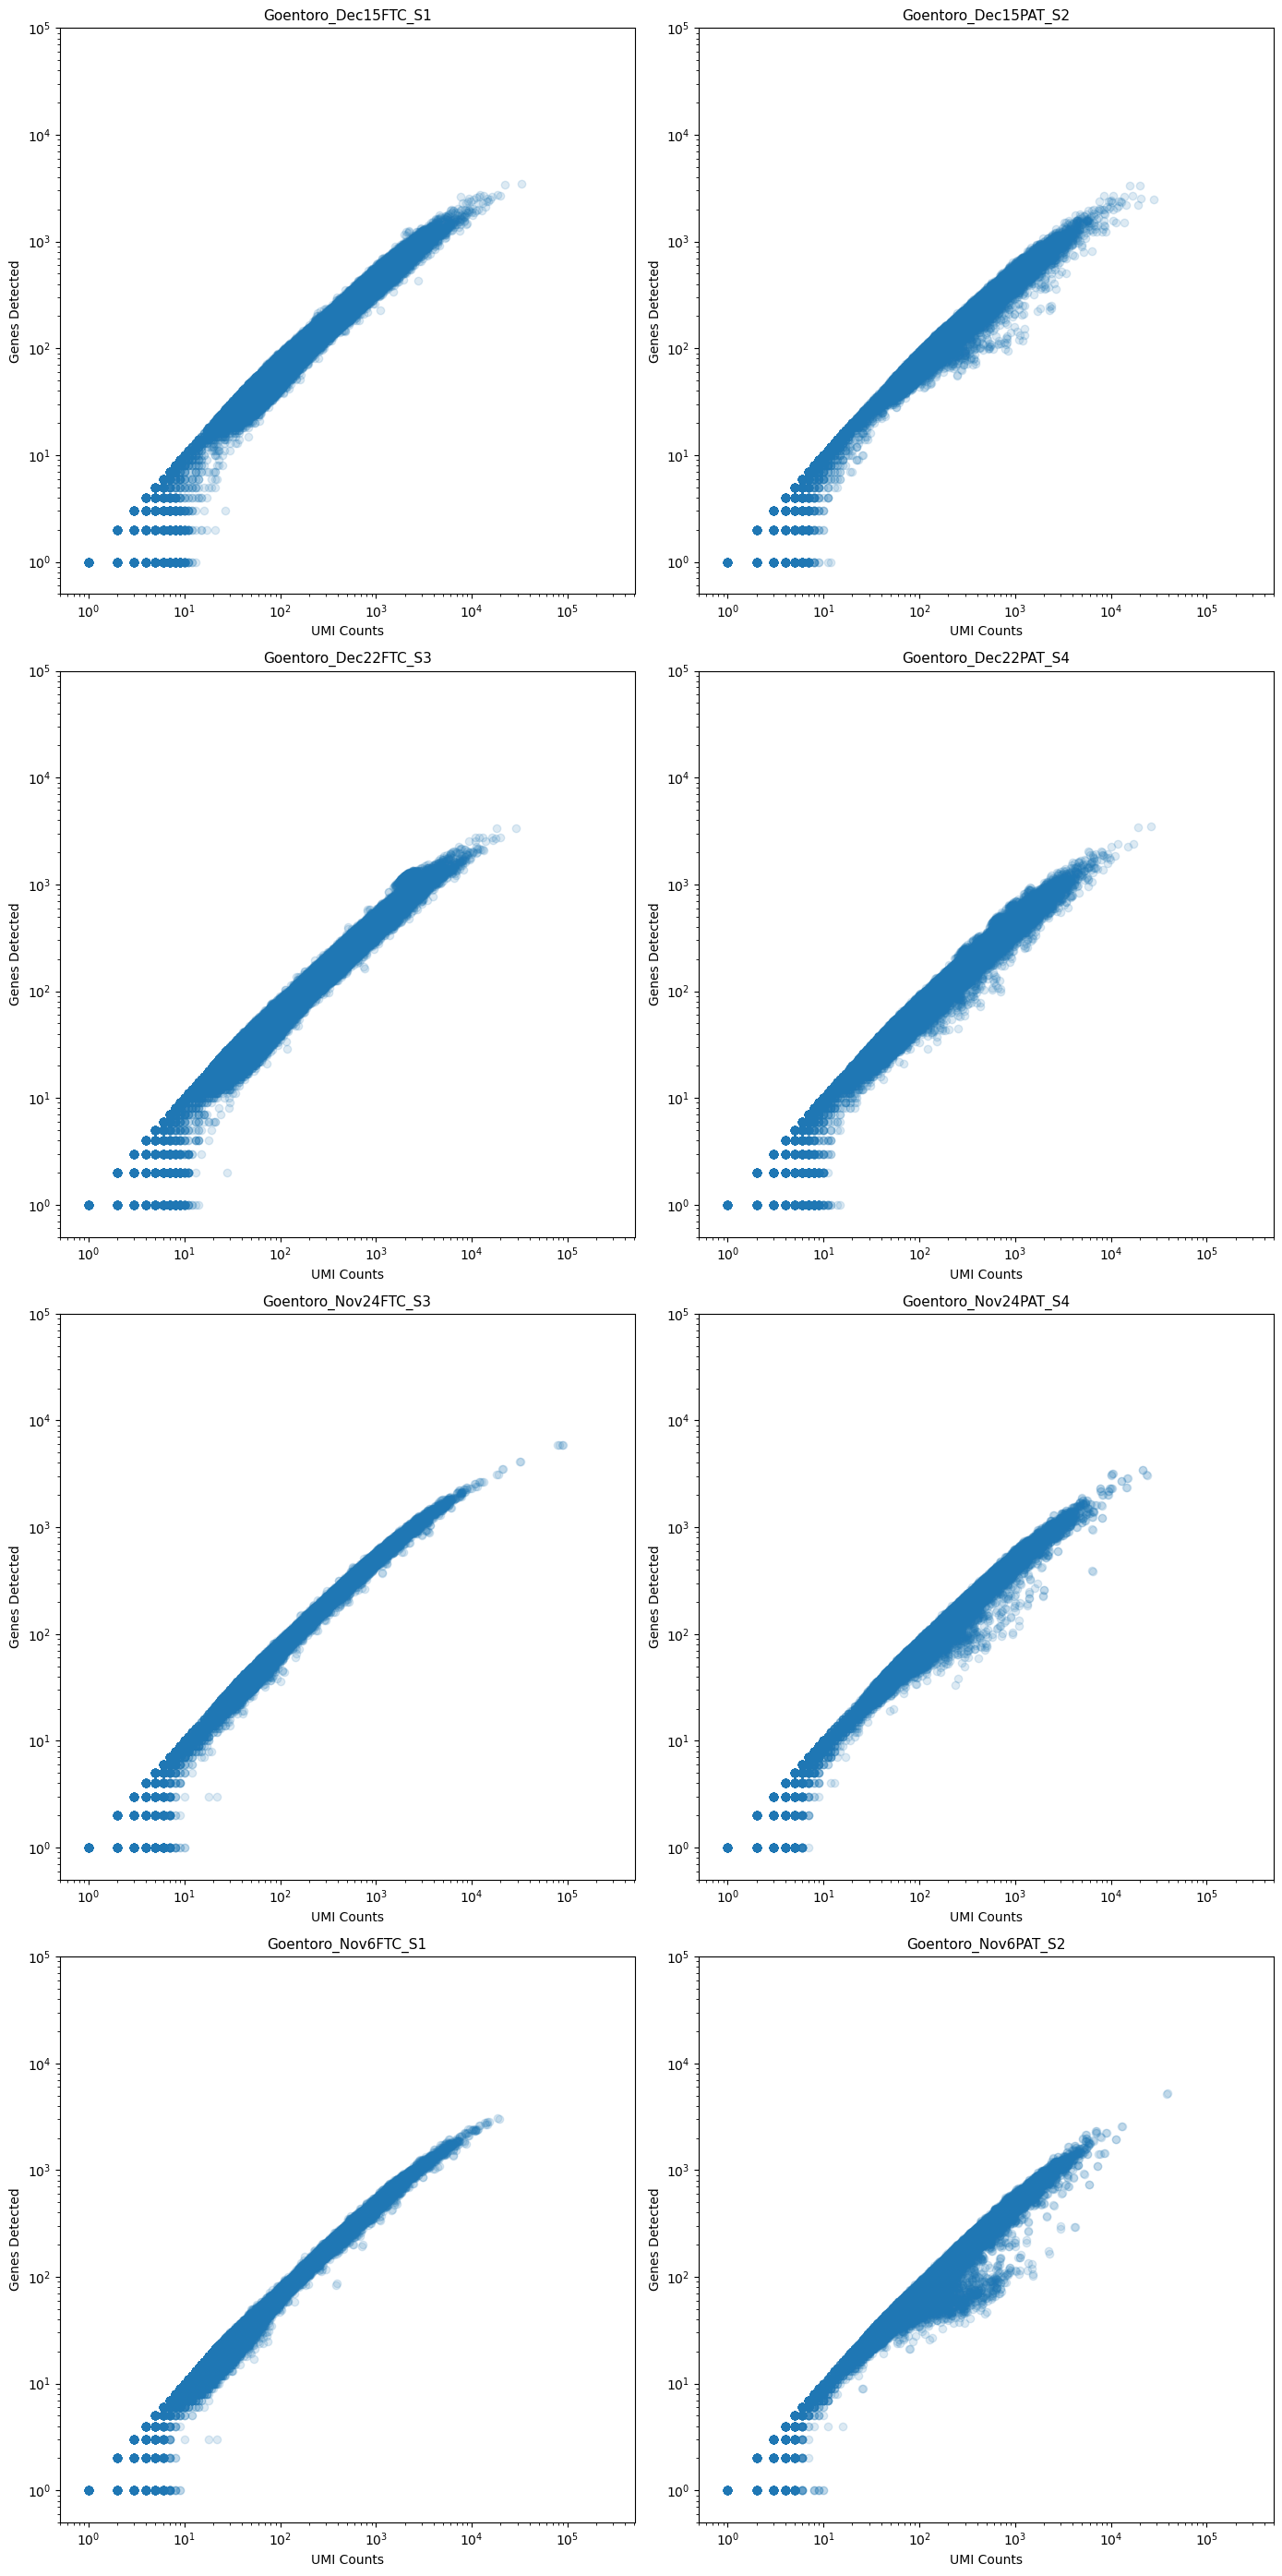

In [40]:
#Plot 1:Genes detected vs UMI
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

for ax, (name, a) in zip(axes, adatas.items()):
    x = a.obs["total_counts"]
    y = a.obs["n_genes_by_counts"]

    ax.scatter(x, y, alpha=0.15)
    ax.set_xscale("log")
    ax.set_yscale("log", nonpositive="clip")

    ax.set_xlim((0.5, 500000))
    ax.set_ylim((0.5, 100000))

    ax.set_title(name.replace("_counts_unfiltered_merged", ""), fontsize=11)
    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Genes Detected")

plt.tight_layout()
plt.savefig("Genes_UMI.png", dpi=300, bbox_inches="tight")
plt.show()

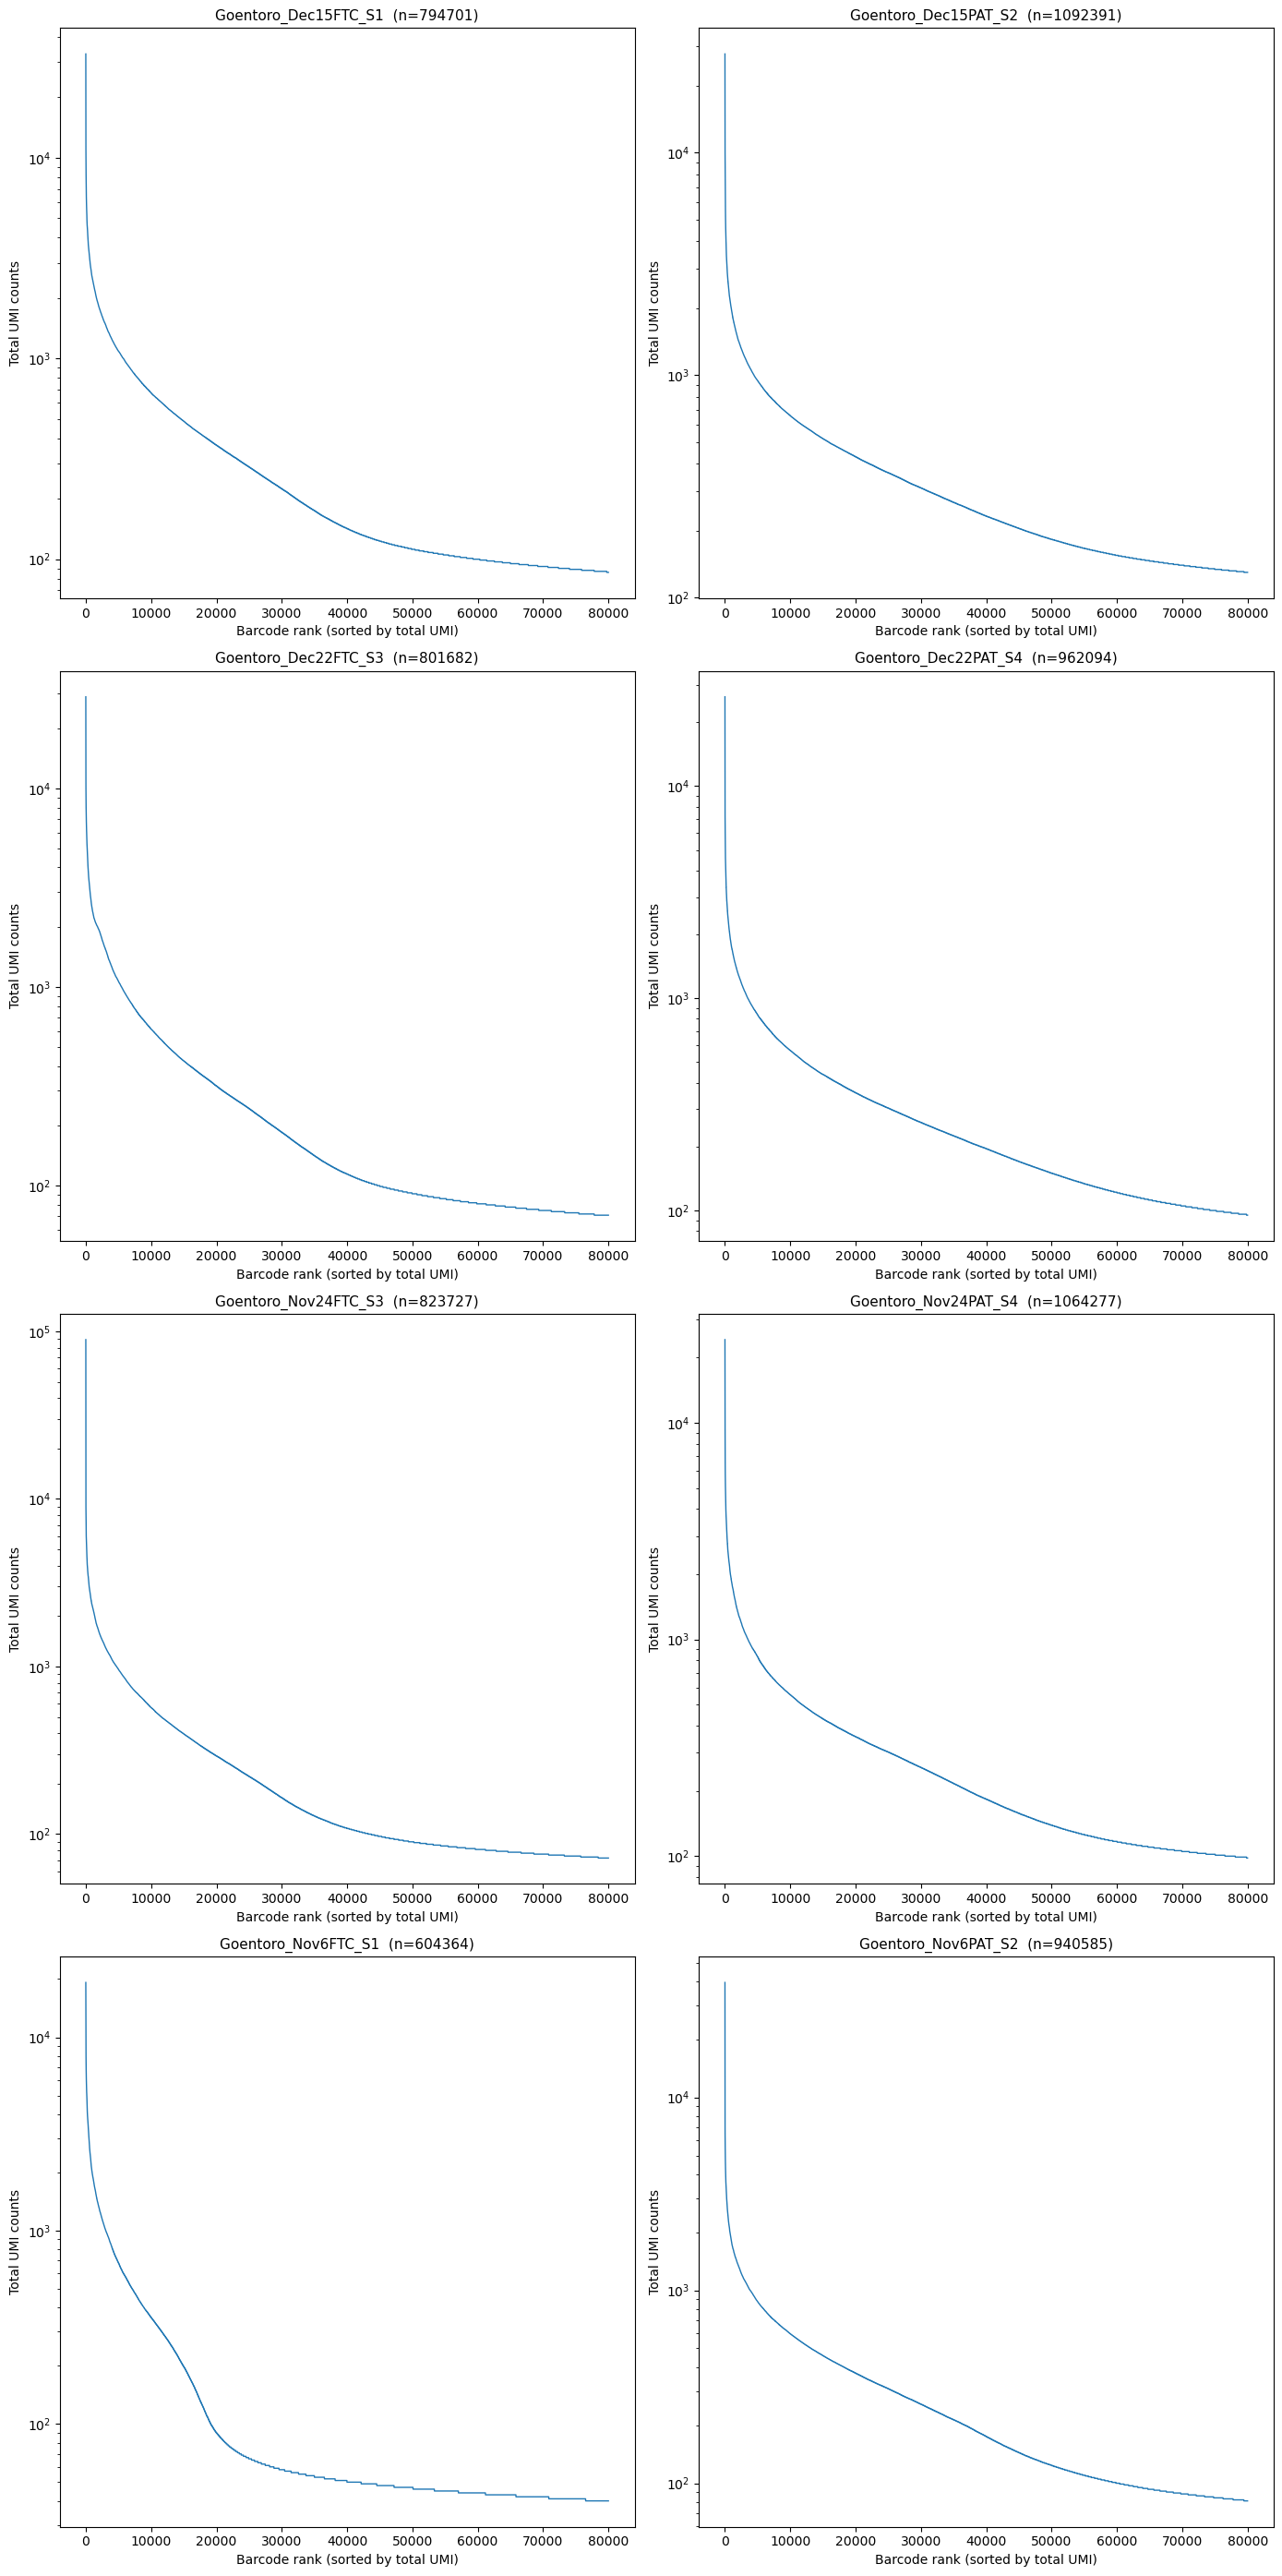

In [6]:
#Plot 2
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]
    x = a.obs["total_counts"].to_numpy()
    x_sorted = np.sort(x)[::-1]
    x_sorted = x_sorted[:80000] 

    ax.plot(x_sorted, linewidth=1)
    ax.set_yscale("log")
    ax.set_xlabel("Barcode rank (sorted by total UMI)")
    ax.set_ylabel("Total UMI counts")

    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_title(f"{title}  (n={a.n_obs})", fontsize=11)

plt.tight_layout()
plt.savefig("Knee_Gene.png", dpi=300, bbox_inches="tight")
plt.show()

Goentoro_Dec15FTC_S1: 32,152 cells passed the 200 UMI threshold
Goentoro_Dec15PAT_S2: 45,857 cells passed the 200 UMI threshold
Goentoro_Dec22FTC_S3: 28,567 cells passed the 200 UMI threshold
Goentoro_Dec22PAT_S4: 39,038 cells passed the 200 UMI threshold
Goentoro_Nov24FTC_S3: 26,725 cells passed the 200 UMI threshold
Goentoro_Nov24PAT_S4: 37,201 cells passed the 200 UMI threshold
Goentoro_Nov6FTC_S1: 14,880 cells passed the 200 UMI threshold
Goentoro_Nov6PAT_S2: 36,645 cells passed the 200 UMI threshold


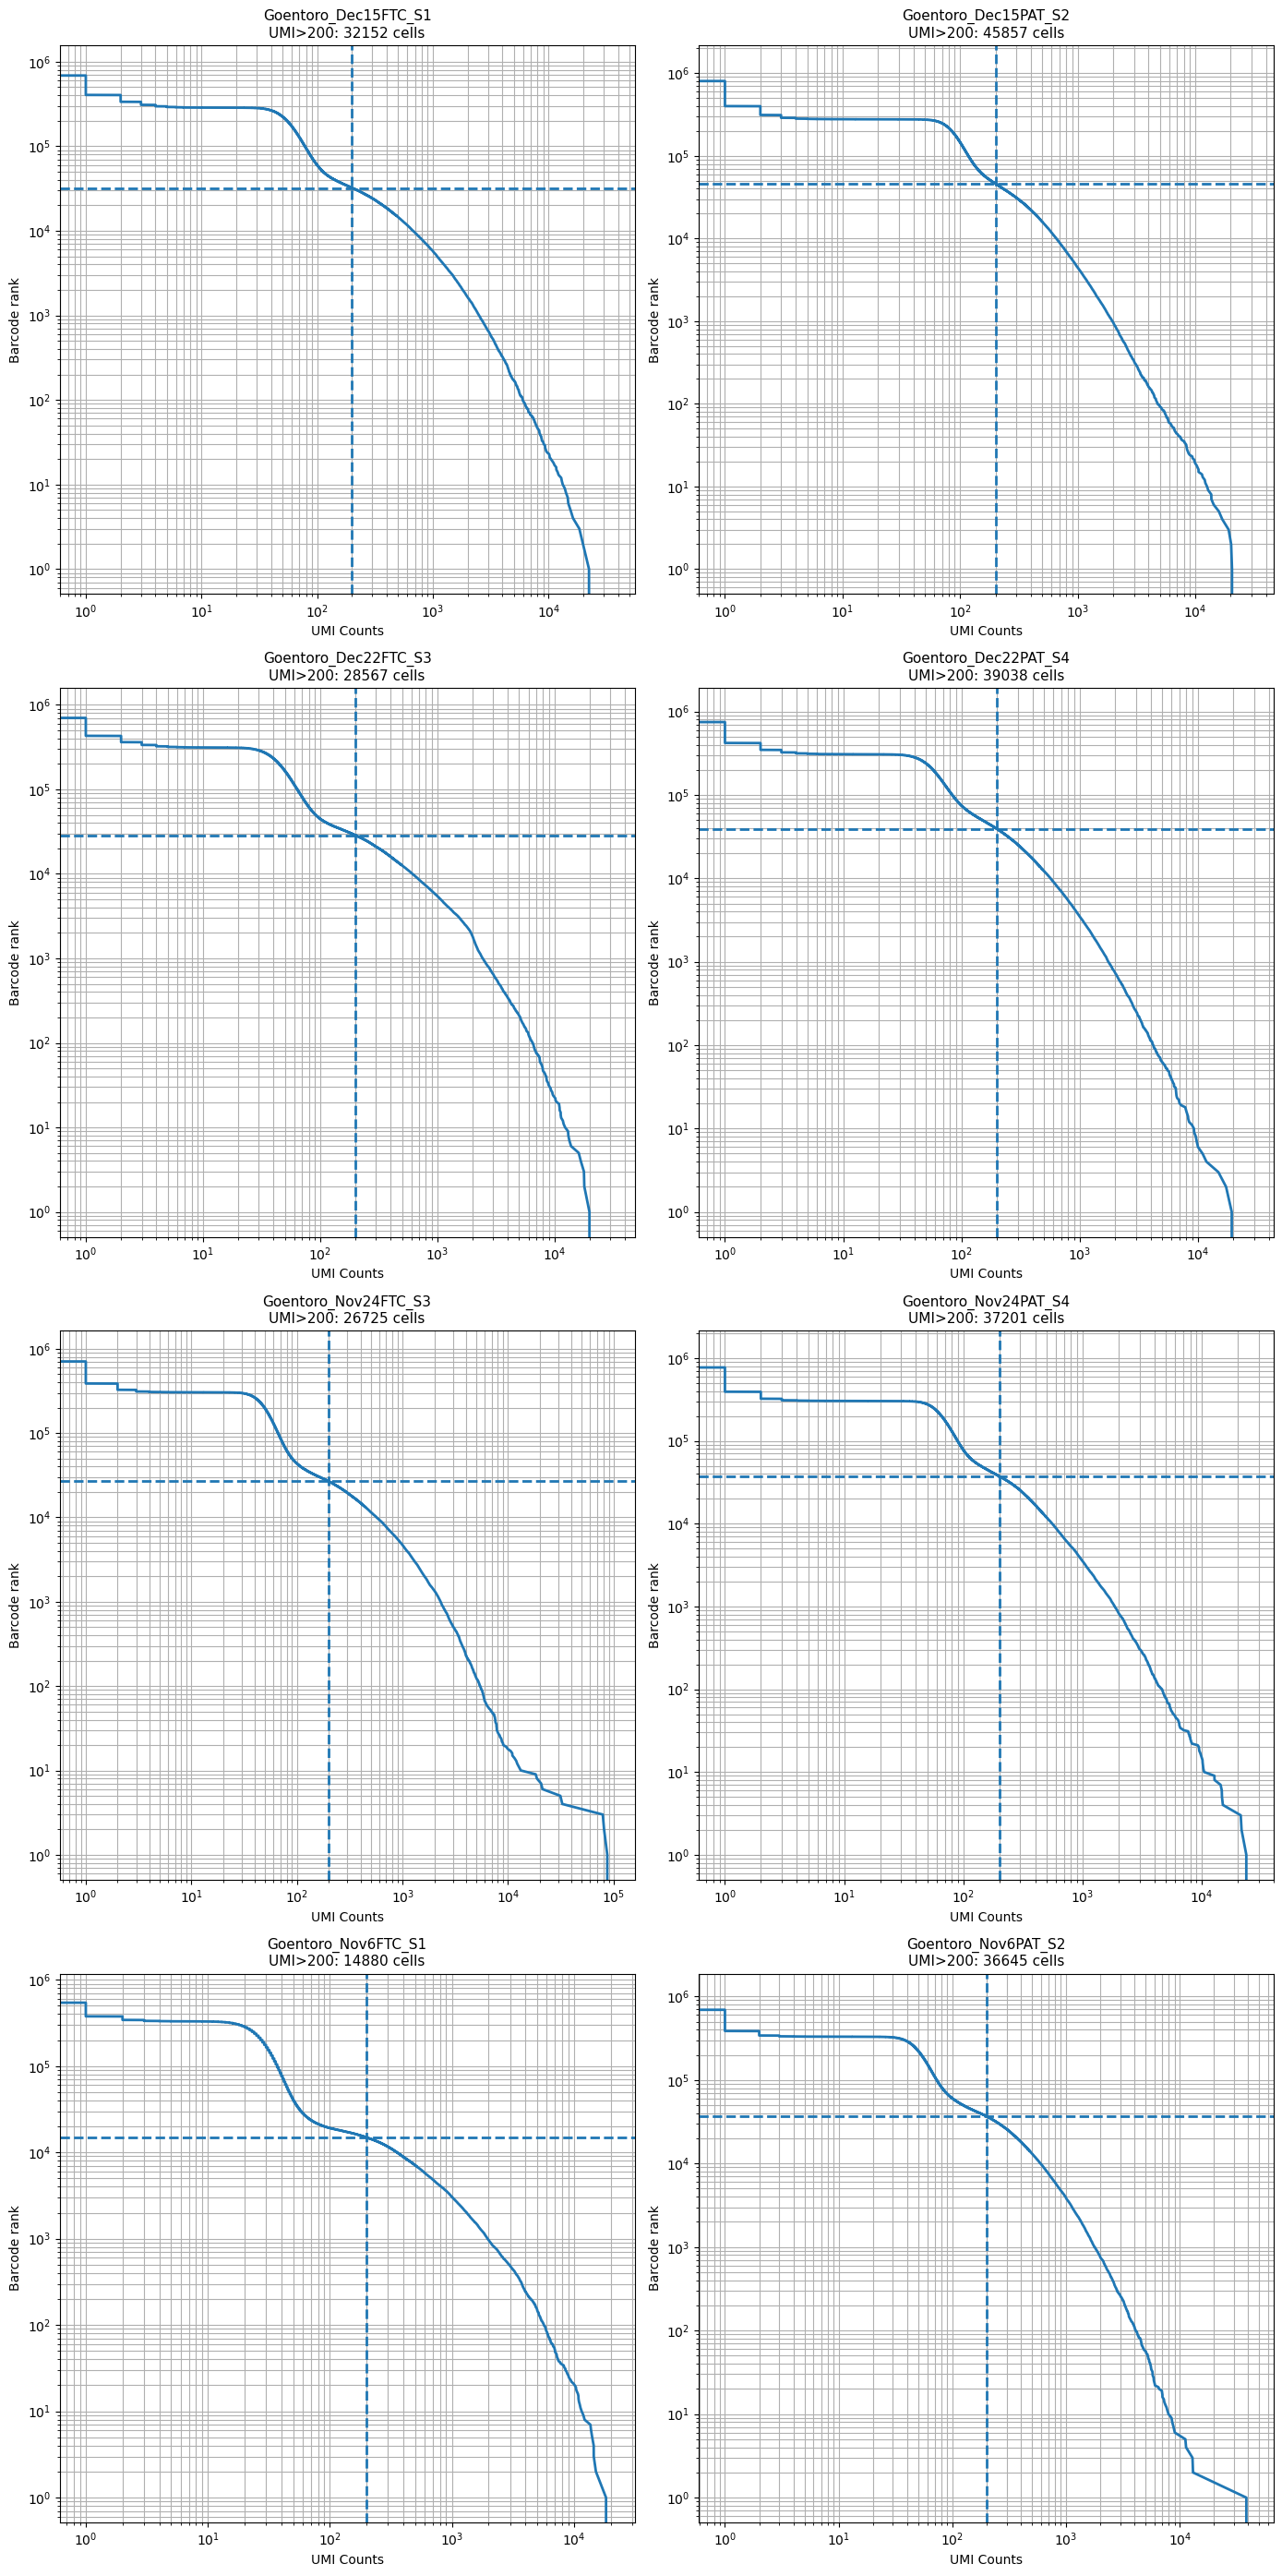

In [10]:
#Plot 3: Knee Plot: UMI
cutoff_umi = 200
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]

    x = a.obs["total_counts"].to_numpy()

    knee = np.sort(x)[::-1]
    cell_set = np.arange(len(knee))

    num_cells = int((knee > cutoff_umi).sum())
    last_rank = max(num_cells - 1, 0)
    
    print(f"{name.replace('_counts_unfiltered_merged','')}: "
          f"{num_cells:,.0f} cells passed the {cutoff_umi} UMI threshold")

    ax.loglog(knee, cell_set, linewidth=2)
    ax.axvline(x=cutoff_umi, linewidth=2, linestyle="--")
    ax.axhline(y=last_rank, linewidth=2, linestyle="--")

    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_title(f"{title}\nUMI>{cutoff_umi}: {num_cells} cells", fontsize=11)

    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Barcode rank")
    ax.grid(True, which="both")

plt.tight_layout()
plt.savefig("Knee_UMI.png", dpi=300, bbox_inches="tight")
plt.show()

Goentoro_Nov6FTC_S1: 14,880 cells passed the 200 UMI threshold
Goentoro_Nov6PAT_S2: 36,645 cells passed the 200 UMI threshold
Goentoro_Nov24FTC_S3: 26,725 cells passed the 200 UMI threshold
Goentoro_Nov24PAT_S4: 37,201 cells passed the 200 UMI threshold
Goentoro_Dec15FTC_S1: 32,152 cells passed the 200 UMI threshold
Goentoro_Dec15PAT_S2: 45,857 cells passed the 200 UMI threshold
Goentoro_Dec22FTC_S3: 28,567 cells passed the 200 UMI threshold
Goentoro_Dec22PAT_S4: 39,038 cells passed the 200 UMI threshold


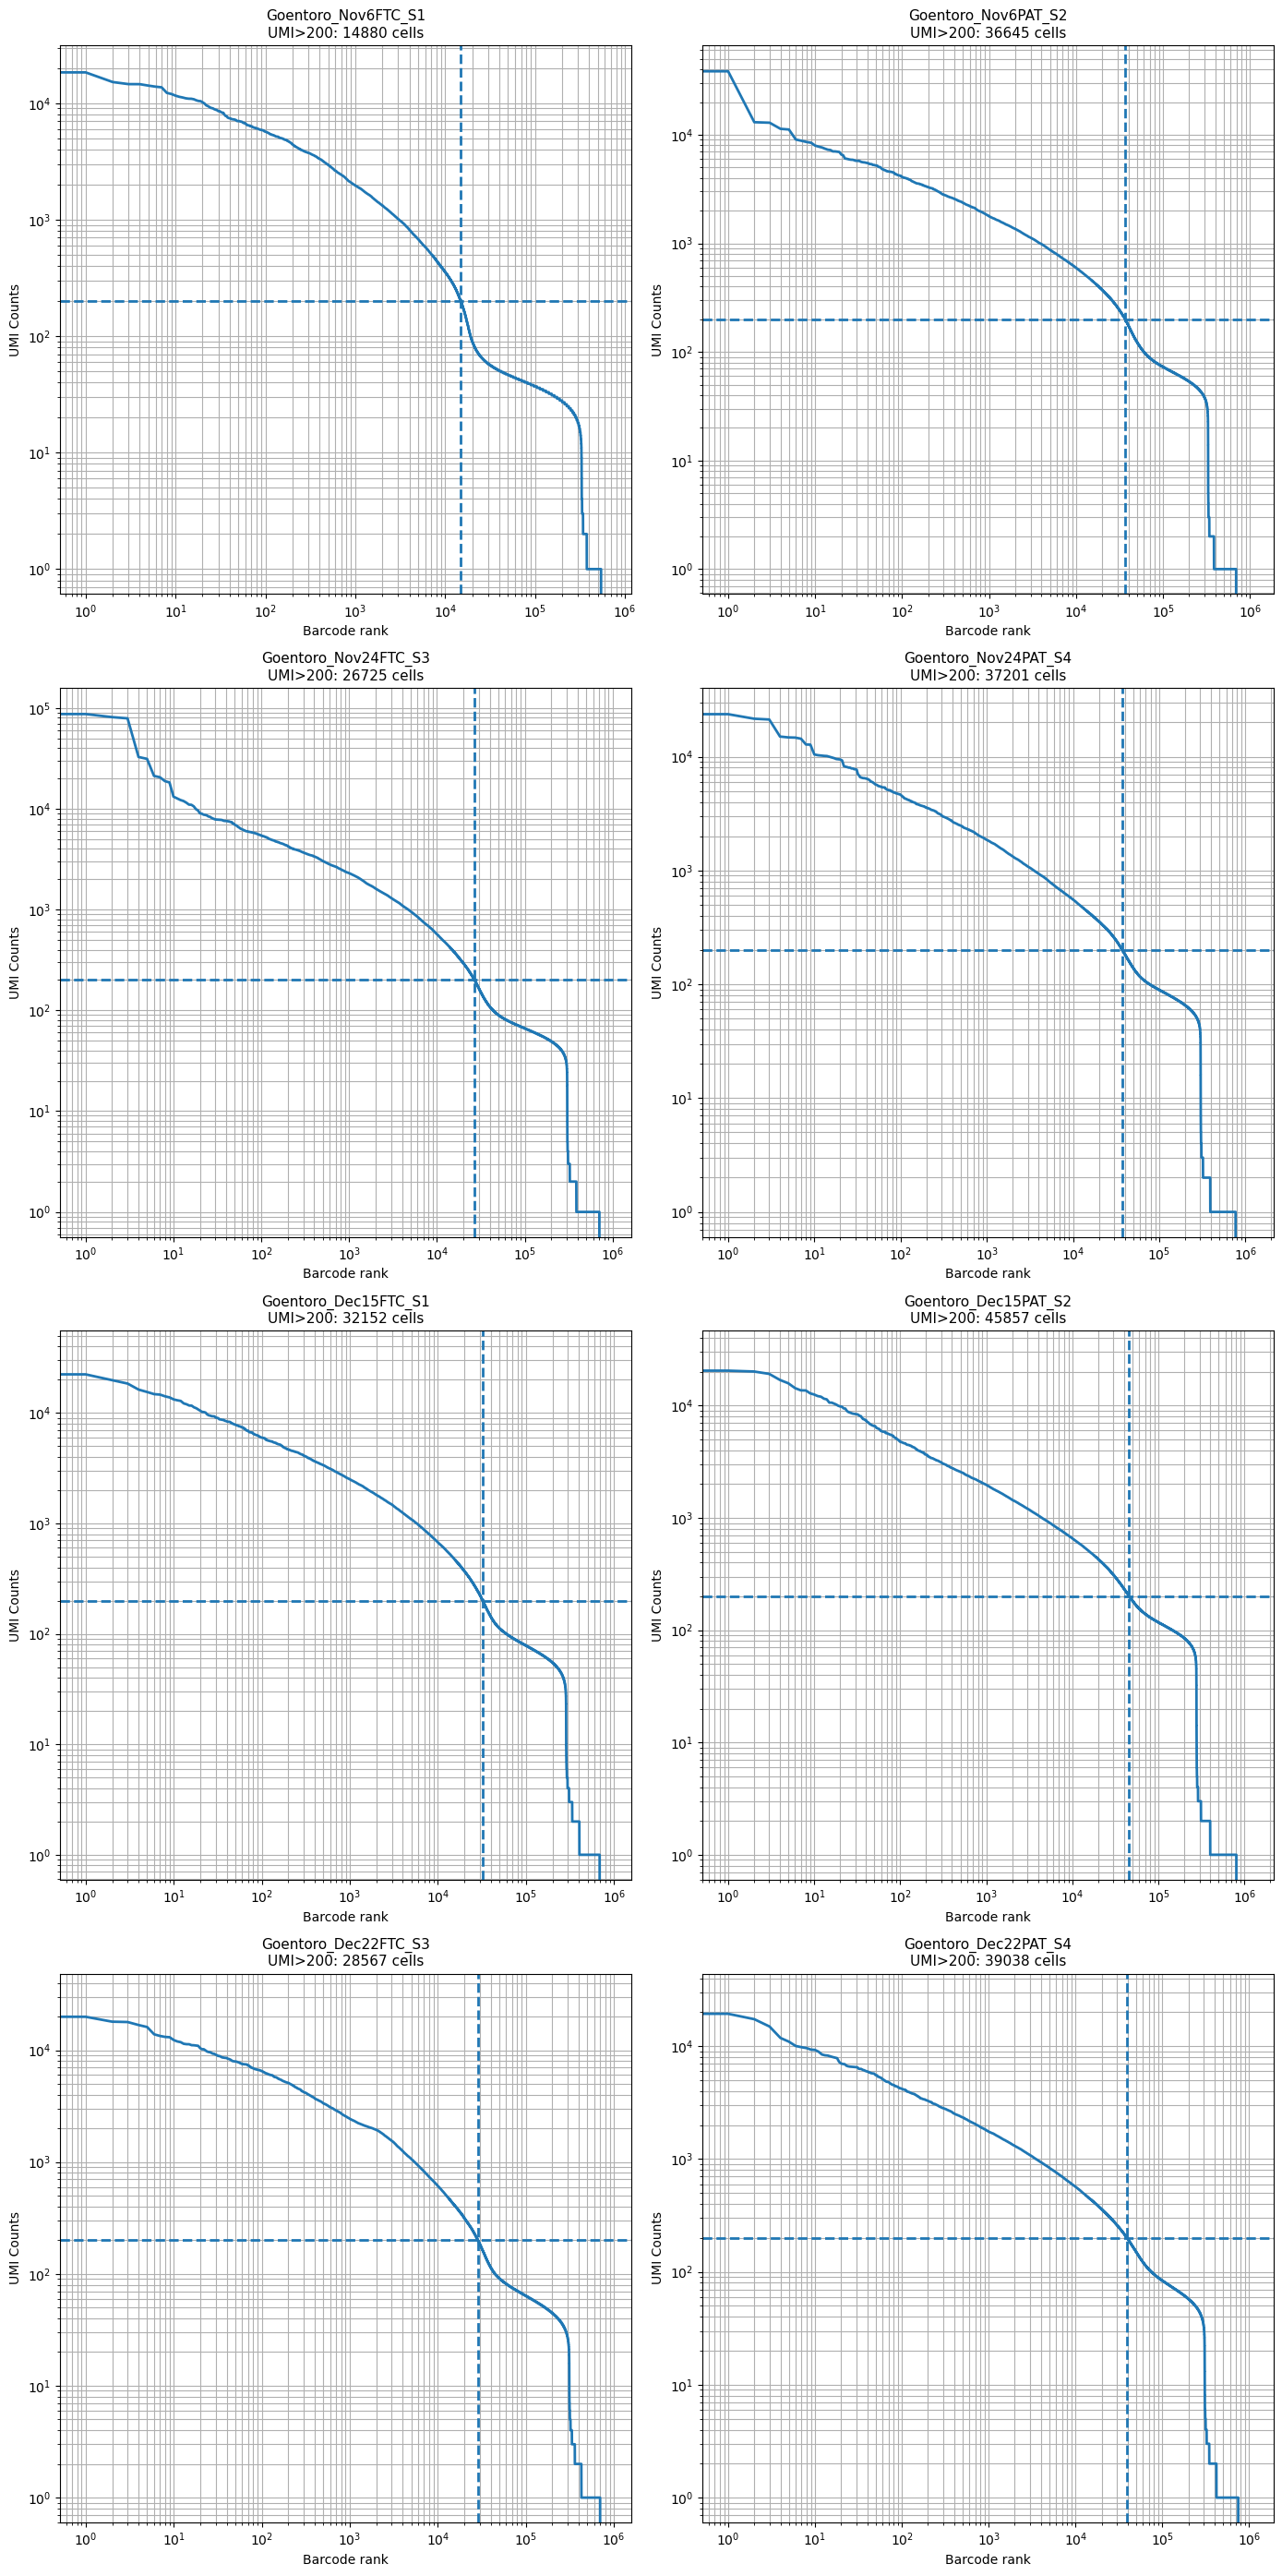

In [9]:
#Plot 3: Knee Plot: UMI
cutoff_umi = 200
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]

    x = a.obs["total_counts"].to_numpy()

    knee = np.sort(x)[::-1]
    cell_set = np.arange(len(knee))

    num_cells = int((knee > cutoff_umi).sum())
    last_rank = max(num_cells - 1, 0)
    
    print(f"{name.replace('_counts_unfiltered_merged','')}: "
          f"{num_cells:,.0f} cells passed the {cutoff_umi} UMI threshold")

    ax.loglog(cell_set, knee, linewidth=2)
    ax.axhline(y=cutoff_umi, linewidth=2, linestyle="--")
    ax.axvline(x=last_rank, linewidth=2, linestyle="--")

    ax.set_xlabel("Barcode rank")
    ax.set_ylabel("UMI Counts")


    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_title(f"{title}\nUMI>{cutoff_umi}: {num_cells} cells", fontsize=11)

    ax.grid(True, which="both")

plt.tight_layout()
plt.savefig("Knee_UMI_barcode.png", dpi=300, bbox_inches="tight")
plt.show()

Goentoro_Dec15FTC_S1: 19,008 cells passed the 200 gene threshold
Goentoro_Dec15PAT_S2: 27,446 cells passed the 200 gene threshold
Goentoro_Dec22FTC_S3: 15,710 cells passed the 200 gene threshold
Goentoro_Dec22PAT_S4: 18,974 cells passed the 200 gene threshold
Goentoro_Nov24FTC_S3: 18,929 cells passed the 200 gene threshold
Goentoro_Nov24PAT_S4: 23,087 cells passed the 200 gene threshold
Goentoro_Nov6FTC_S1: 10,184 cells passed the 200 gene threshold
Goentoro_Nov6PAT_S2: 24,240 cells passed the 200 gene threshold


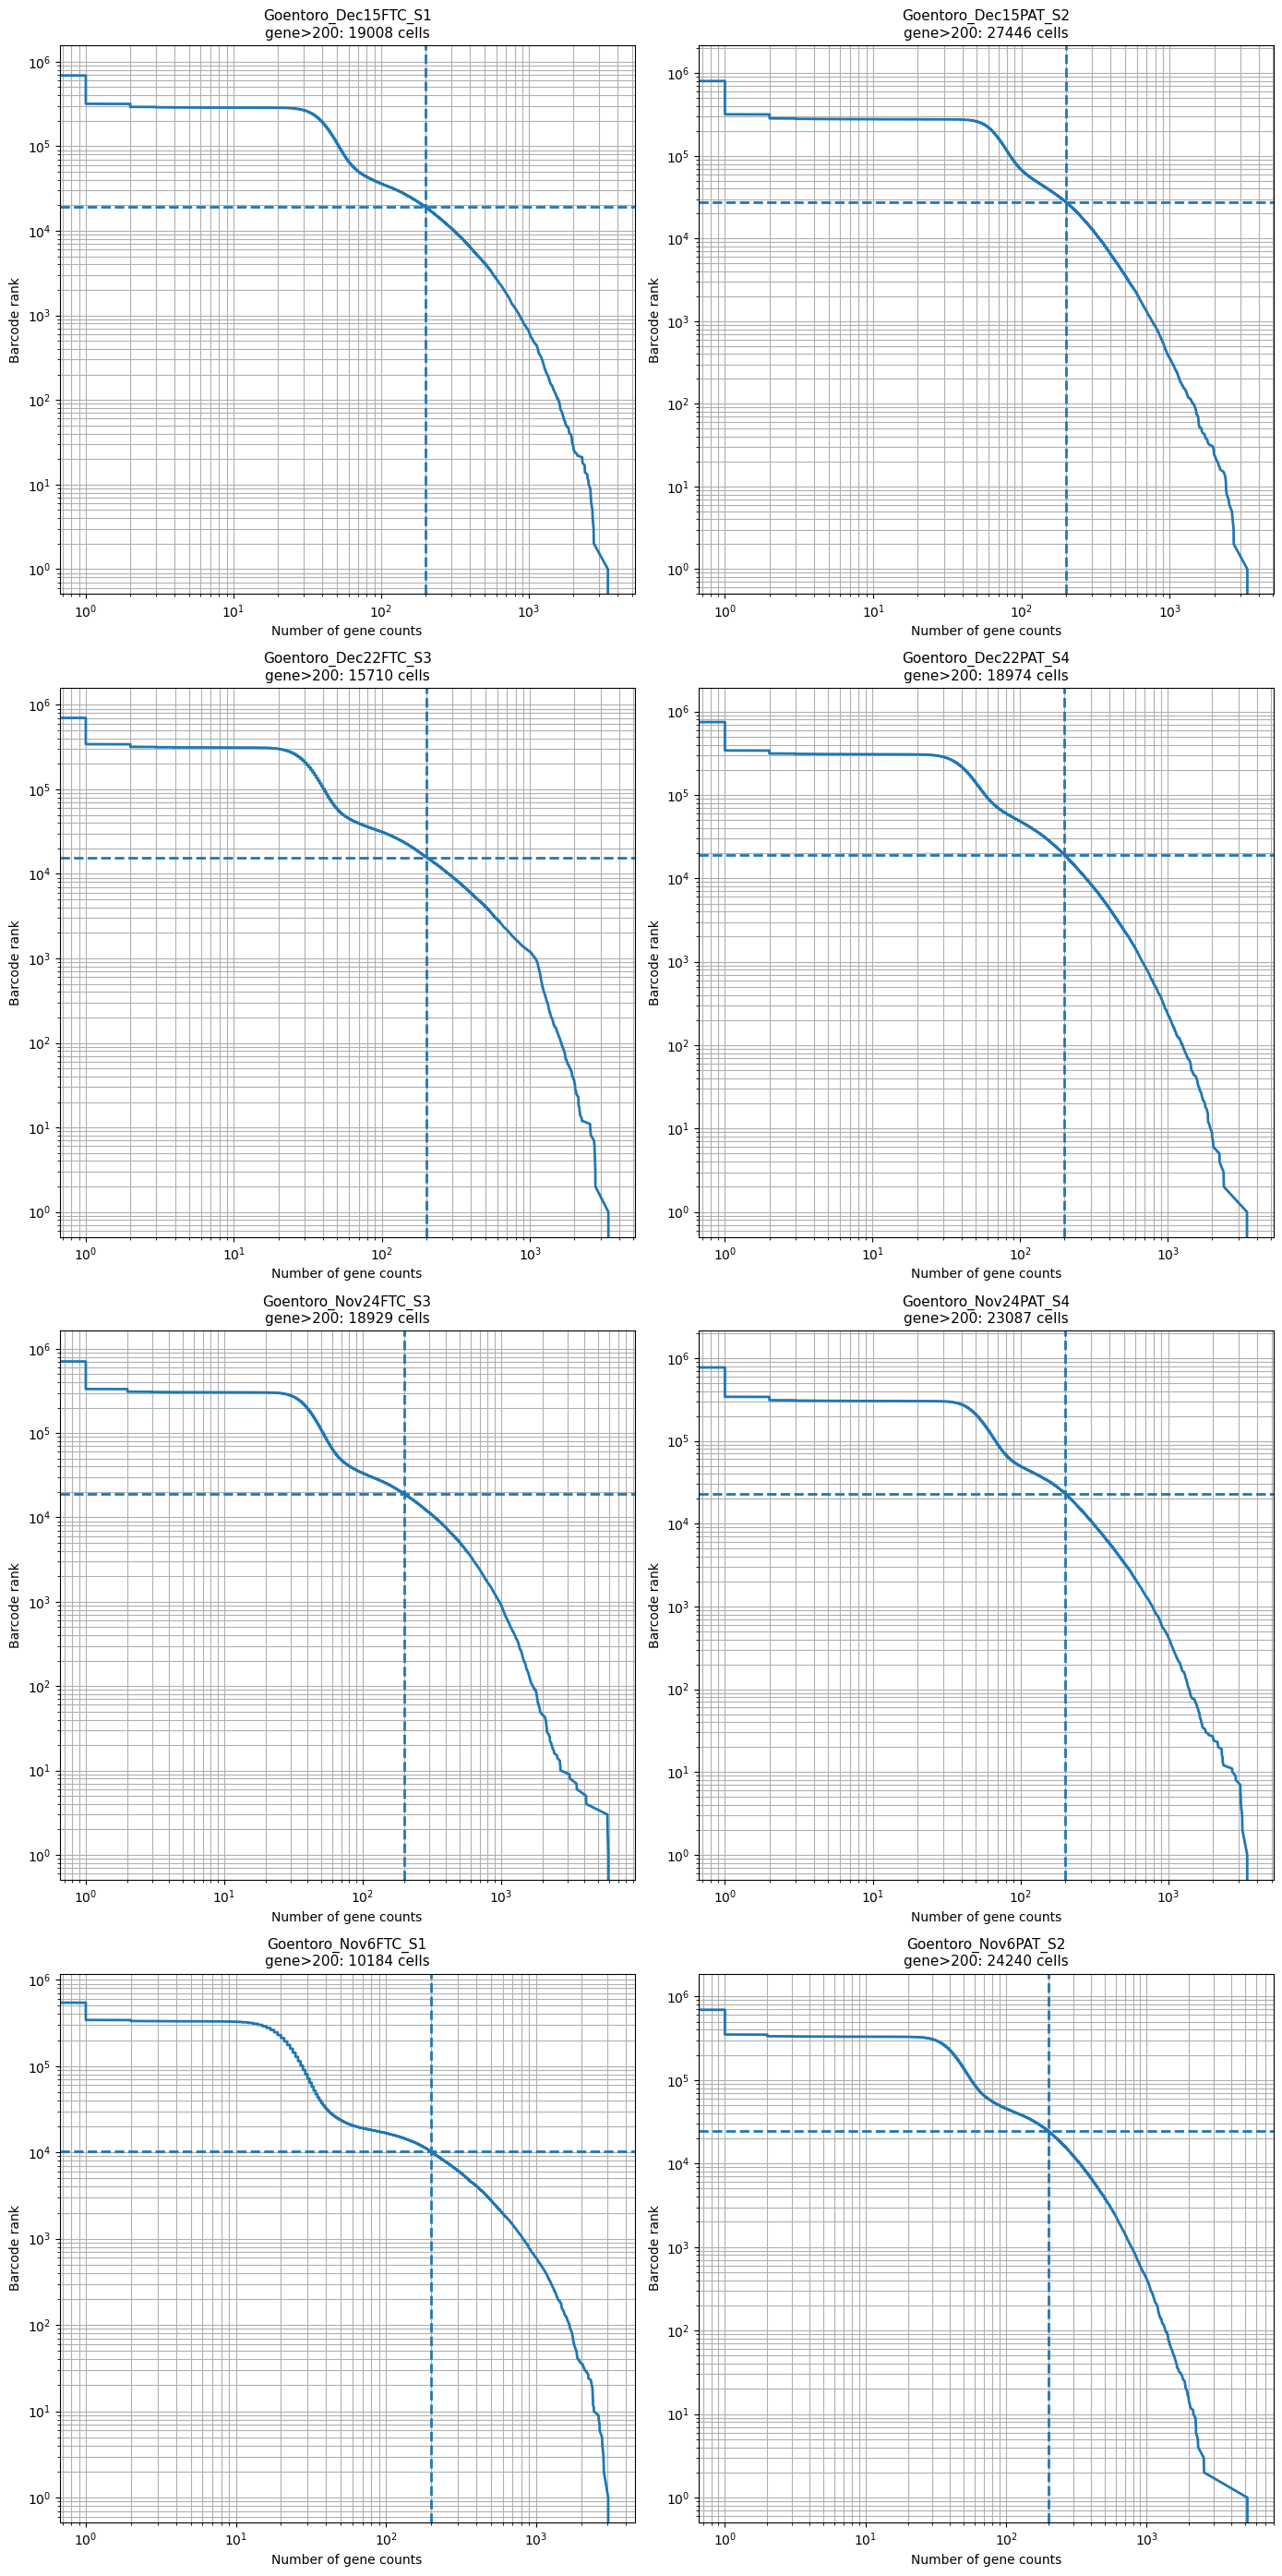

In [9]:
cutoff_gene = 200
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]

    x = a.obs["n_genes_by_counts"].to_numpy()

    knee = np.sort(x)[::-1]
    cell_set = np.arange(len(knee))

    num_cells = int((knee > cutoff_gene).sum())
    last_rank = max(num_cells - 1, 0)
    print(f"{name.replace('_counts_unfiltered_merged','')}: "
          f"{num_cells:,.0f} cells passed the {cutoff_gene} gene threshold")

    ax.loglog(knee, cell_set, linewidth=2)
    ax.axvline(x=cutoff_gene, linewidth=2, linestyle="--")
    ax.axhline(y=last_rank, linewidth=2, linestyle="--")


    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_title(f"{title}\ngene>{cutoff_gene}: {num_cells} cells", fontsize=11)

    ax.set_xlabel("Number of gene counts")
    ax.set_ylabel("Barcode rank")
    ax.grid(True, which="both")

plt.tight_layout()
#plt.savefig("Knee_Gene.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# one-time: FlyBase gene id -> gene symbol (external_gene_name)
mito_gene_names_fly = sc.queries.mitochondrial_genes(
    "dmelanogaster",
    chromosome="mitochondrion_genome"
)

mito_gene_symbols = set(
    mito_gene_names_fly.iloc[:, 0].astype(str).str.upper()
)

gene_map = sc.queries.biomart_annotations(
    "dmelanogaster",
    ["flybase_gene_id", "external_gene_name"],
).rename(columns={
    "flybase_gene_id": "gene_id",
    "external_gene_name": "gene_symbol"
})

fbgn_to_symbol = dict(
    zip(gene_map["gene_id"].astype(str), gene_map["gene_symbol"].astype(str))
)

In [12]:
for name, a in adatas.items():
    # 1) Ensure gene_symbol exists (map FBgn -> symbol). If already present, keep it.
    if "gene_symbol" not in a.var.columns:
        a.var["gene_symbol"] = pd.Index(a.var_names.astype(str)).map(fbgn_to_symbol)

    # 2) Mark mitochondrial genes (robust to NaNs)
    a.var["is_mito"] = (
        a.var["gene_symbol"]
        .astype(str)
        .str.upper()
        .isin(mito_gene_symbols)
    )

    # 3) Compute percent_mito per cell
    mito_counts = a[:, a.var["is_mito"]].X.sum(axis=1)

    # Prefer existing QC metric if present; otherwise compute from X
    if "total_counts" in a.obs.columns:
        total_counts = a.obs["total_counts"].to_numpy()
    else:
        total_counts = a.X.sum(axis=1)

    mito_counts = mito_counts.A1 if hasattr(mito_counts, "A1") else np.ravel(mito_counts)
    total_counts = total_counts.A1 if hasattr(total_counts, "A1") else np.ravel(total_counts)

    a.obs["percent_mito"] = np.divide(
        mito_counts * 100,
        total_counts,
        out=np.zeros_like(total_counts, dtype=float),
        where=total_counts != 0,
    )

    print(f"[mito] {name}: {a.var['is_mito'].sum()} mito genes; percent_mito computed for {a.n_obs} cells")

[mito] Goentoro_Dec15FTC_S1_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 794701 cells
[mito] Goentoro_Dec15PAT_S2_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 1092391 cells
[mito] Goentoro_Dec22FTC_S3_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 801682 cells
[mito] Goentoro_Dec22PAT_S4_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 962094 cells
[mito] Goentoro_Nov24FTC_S3_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 823727 cells
[mito] Goentoro_Nov24PAT_S4_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 1064277 cells
[mito] Goentoro_Nov6FTC_S1_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 604364 cells
[mito] Goentoro_Nov6PAT_S2_counts_unfiltered_merged: 38 mito genes; percent_mito computed for 940585 cells


In [13]:
cutoff_mito = 15

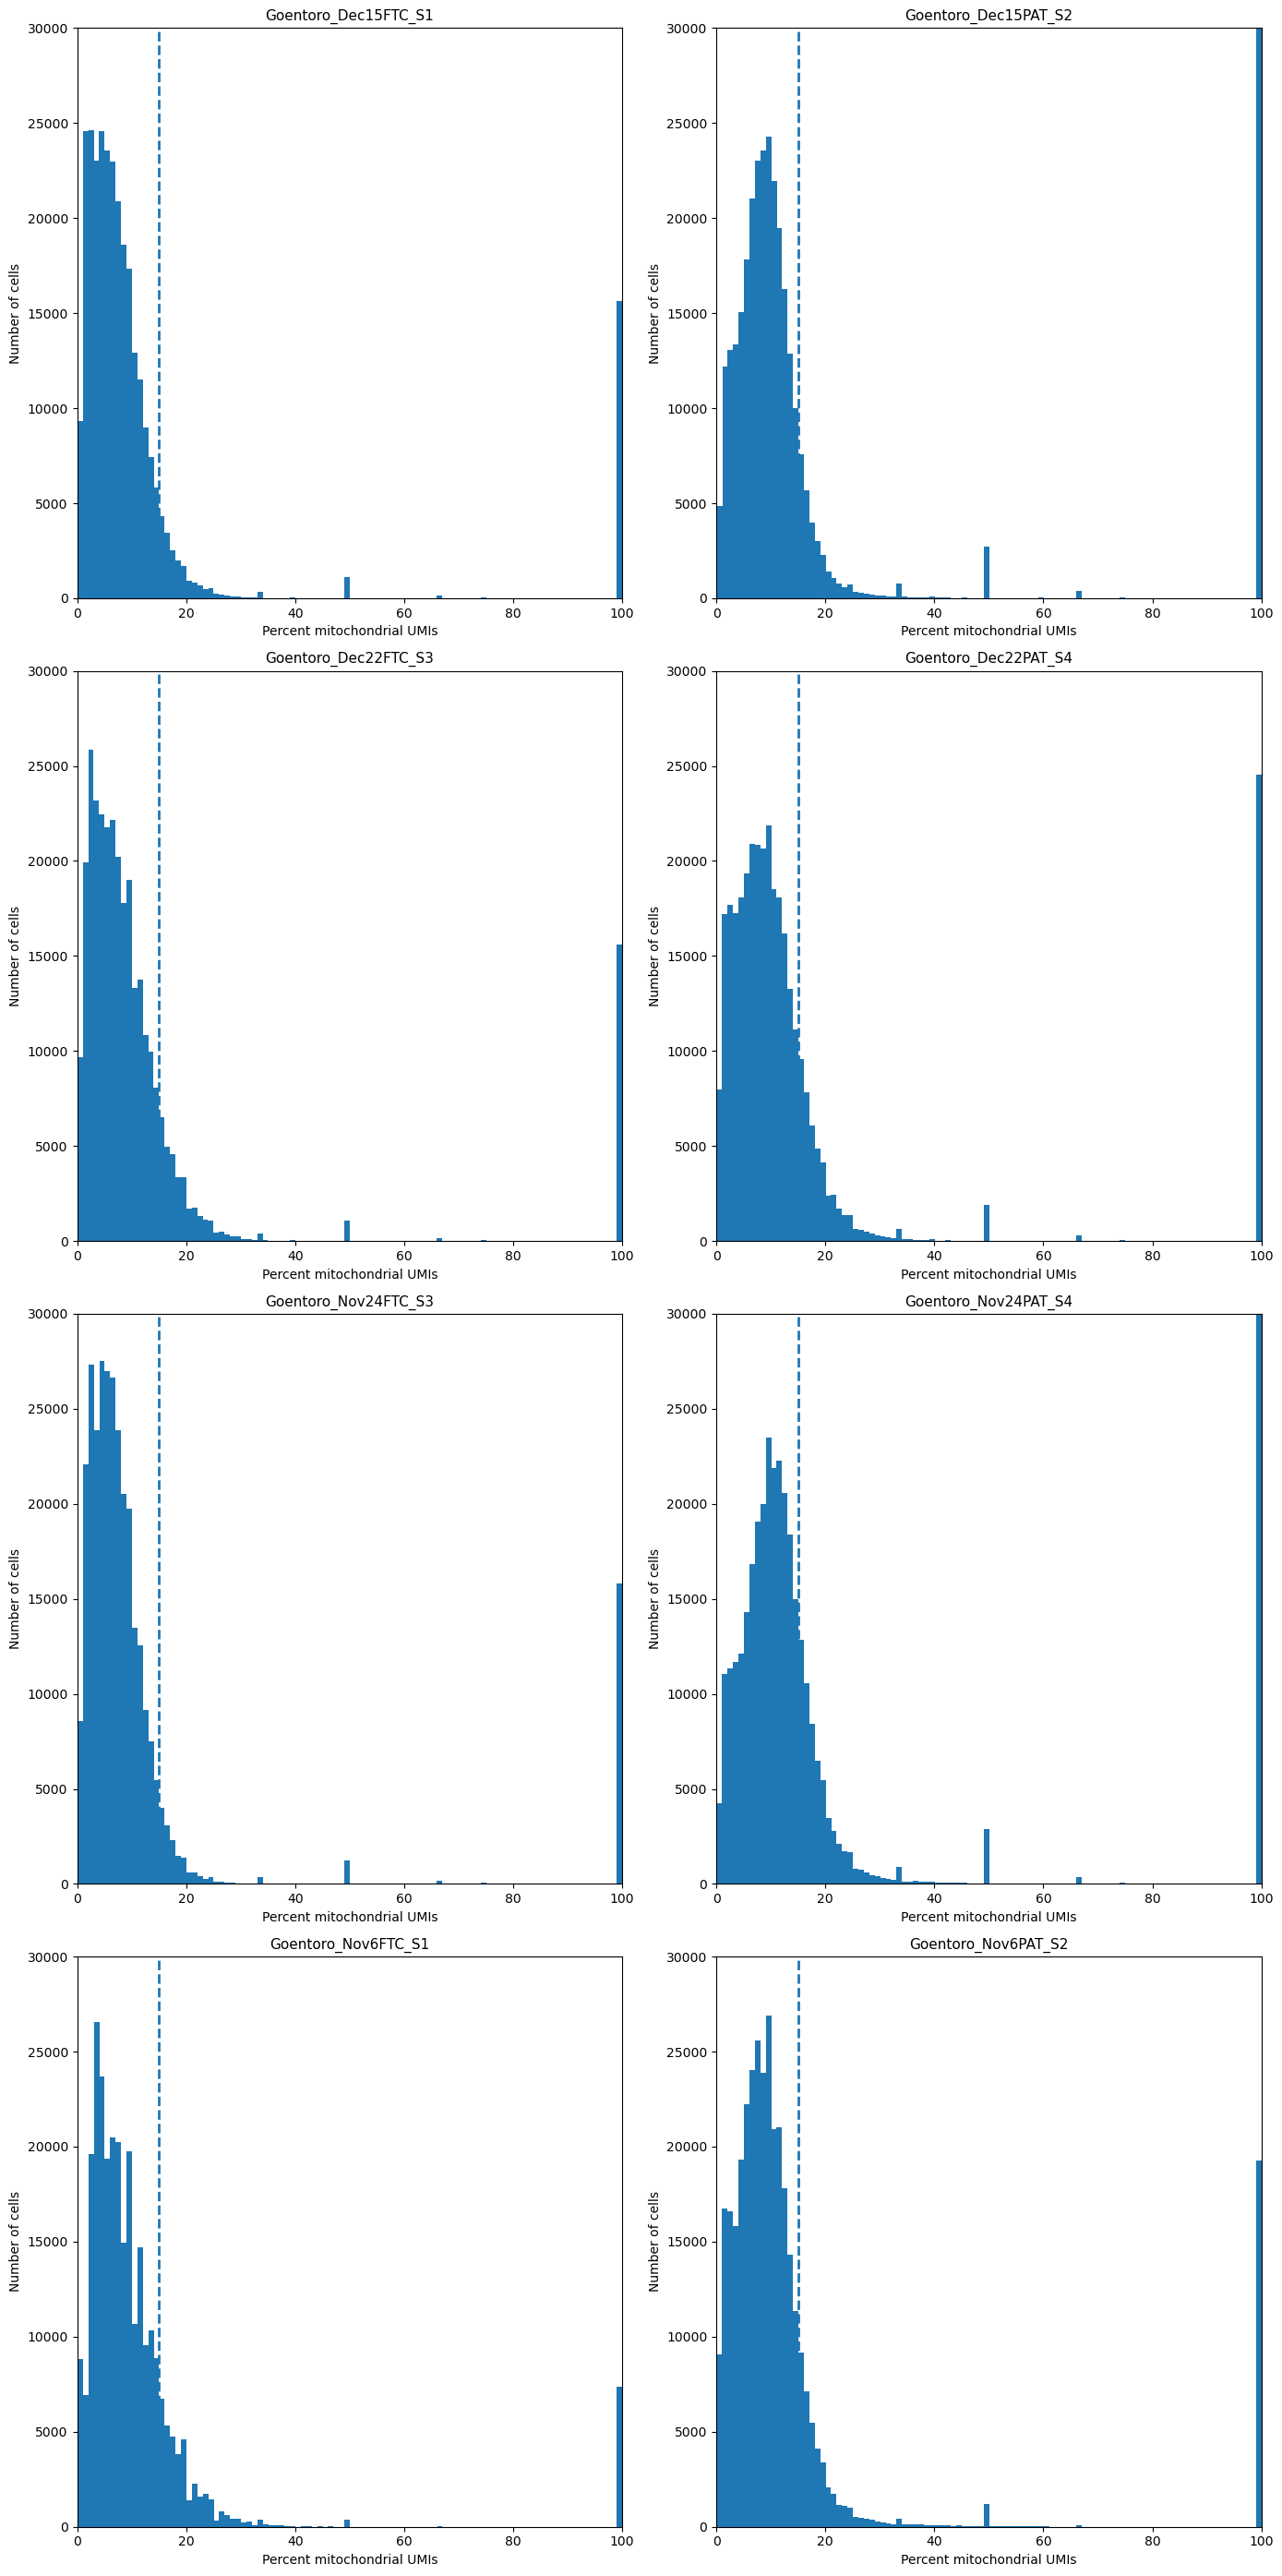

In [36]:
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]
    x = a.obs["percent_mito"].to_numpy()
    x_plot = x[x > 0]   # exclude zeros for visualization only

    ax.hist(x_plot, bins=100)
    ax.axvline(cutoff_mito, linestyle="--", linewidth=2)

    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_xlim(0, 100)   # adjust upper bound as needed
    ax.set_ylim(0, 30000)   # adjust upper bound as needed
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Percent mitochondrial UMIs")
    ax.set_ylabel("Number of cells")

plt.tight_layout()
plt.savefig("Histogram_mito.png", dpi=300, bbox_inches="tight")
plt.show()

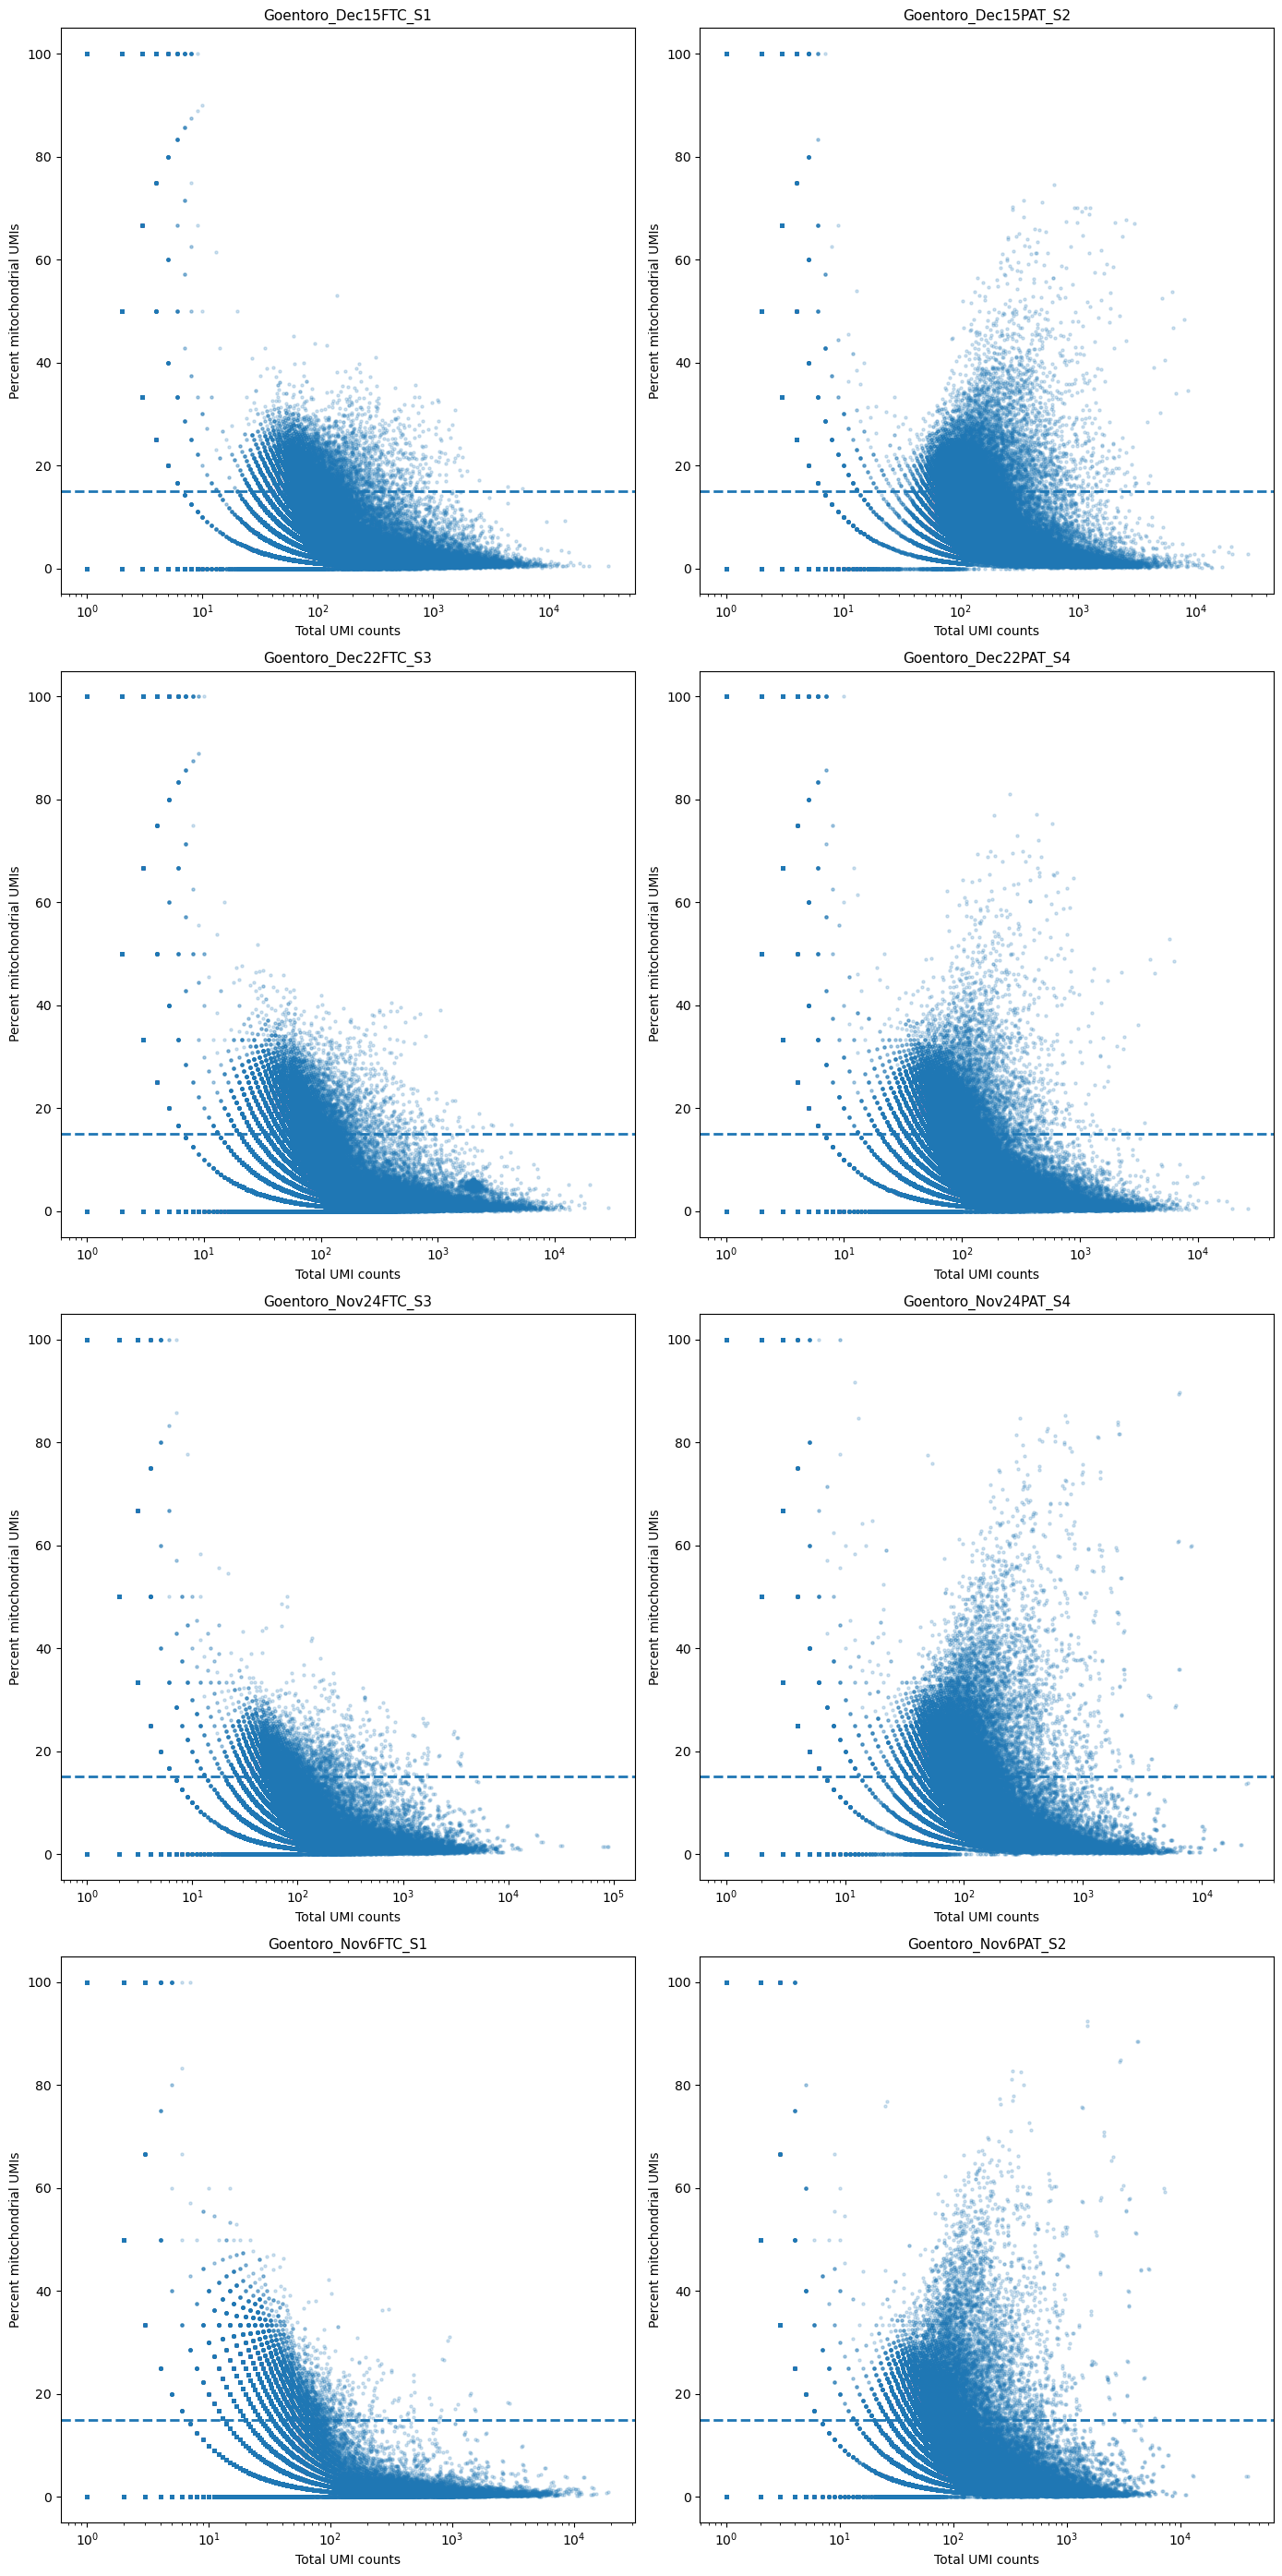

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]

    x = a.obs["total_counts"]
    y = a.obs["percent_mito"]

    ax.scatter(x, y, s=5, alpha=0.2)
    ax.set_xscale("log")
    ax.axhline(cutoff_mito, linestyle="--", linewidth=2)

    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Total UMI counts")
    ax.set_ylabel("Percent mitochondrial UMIs")

plt.tight_layout()
plt.savefig("Scatter_mito.png", dpi=300, bbox_inches="tight")
plt.show()


In [23]:
for name, a in adatas.items():
    # Pick the best available symbol column for rRNA detection
    if "gene_symbol" in a.var.columns:
        symbol_col = "gene_symbol"
    elif "gene_name" in a.var.columns:
        symbol_col = "gene_name"
    else:
        # Last resort: use var_names
        a.var["gene_name"] = a.var_names.astype(str)
        symbol_col = "gene_name"

    # rRNA mask (case-insensitive, safe with NaNs)
    rrna_mask = a.var[symbol_col].astype(str).str.contains("rrna", case=False, na=False)

    # Store boolean mask
    a.var["is_rrna"] = rrna_mask

    # Compute rRNA counts per cell
    rrna_counts = a[:, rrna_mask].X.sum(axis=1)

    # Total counts: prefer existing QC metric
    if "total_counts" in a.obs.columns:
        tc = a.obs["total_counts"].to_numpy()
    else:
        tc = a.X.sum(axis=1)

    rrna_counts = rrna_counts.A1 if hasattr(rrna_counts, "A1") else np.ravel(rrna_counts)
    tc = tc.A1 if hasattr(tc, "A1") else np.ravel(tc)

    # Percent rRNA per cell
    a.obs["percent_rrna"] = np.divide(
        rrna_counts * 100.0,
        tc,
        out=np.zeros_like(tc, dtype=float),
        where=tc != 0,
    )

    print(f"[rRNA] {name}: {int(rrna_mask.sum())} rRNA genes; percent_rrna computed for {a.n_obs} cells")


[rRNA] Goentoro_Dec15FTC_S1_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 794701 cells
[rRNA] Goentoro_Dec15PAT_S2_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 1092391 cells
[rRNA] Goentoro_Dec22FTC_S3_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 801682 cells
[rRNA] Goentoro_Dec22PAT_S4_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 962094 cells
[rRNA] Goentoro_Nov24FTC_S3_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 823727 cells
[rRNA] Goentoro_Nov24PAT_S4_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 1064277 cells
[rRNA] Goentoro_Nov6FTC_S1_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 604364 cells
[rRNA] Goentoro_Nov6PAT_S2_counts_unfiltered_merged: 138 rRNA genes; percent_rrna computed for 940585 cells


In [25]:
rrna_ids = {name: id(a) for name, a in adatas.items()}
print("saved ids")


saved ids


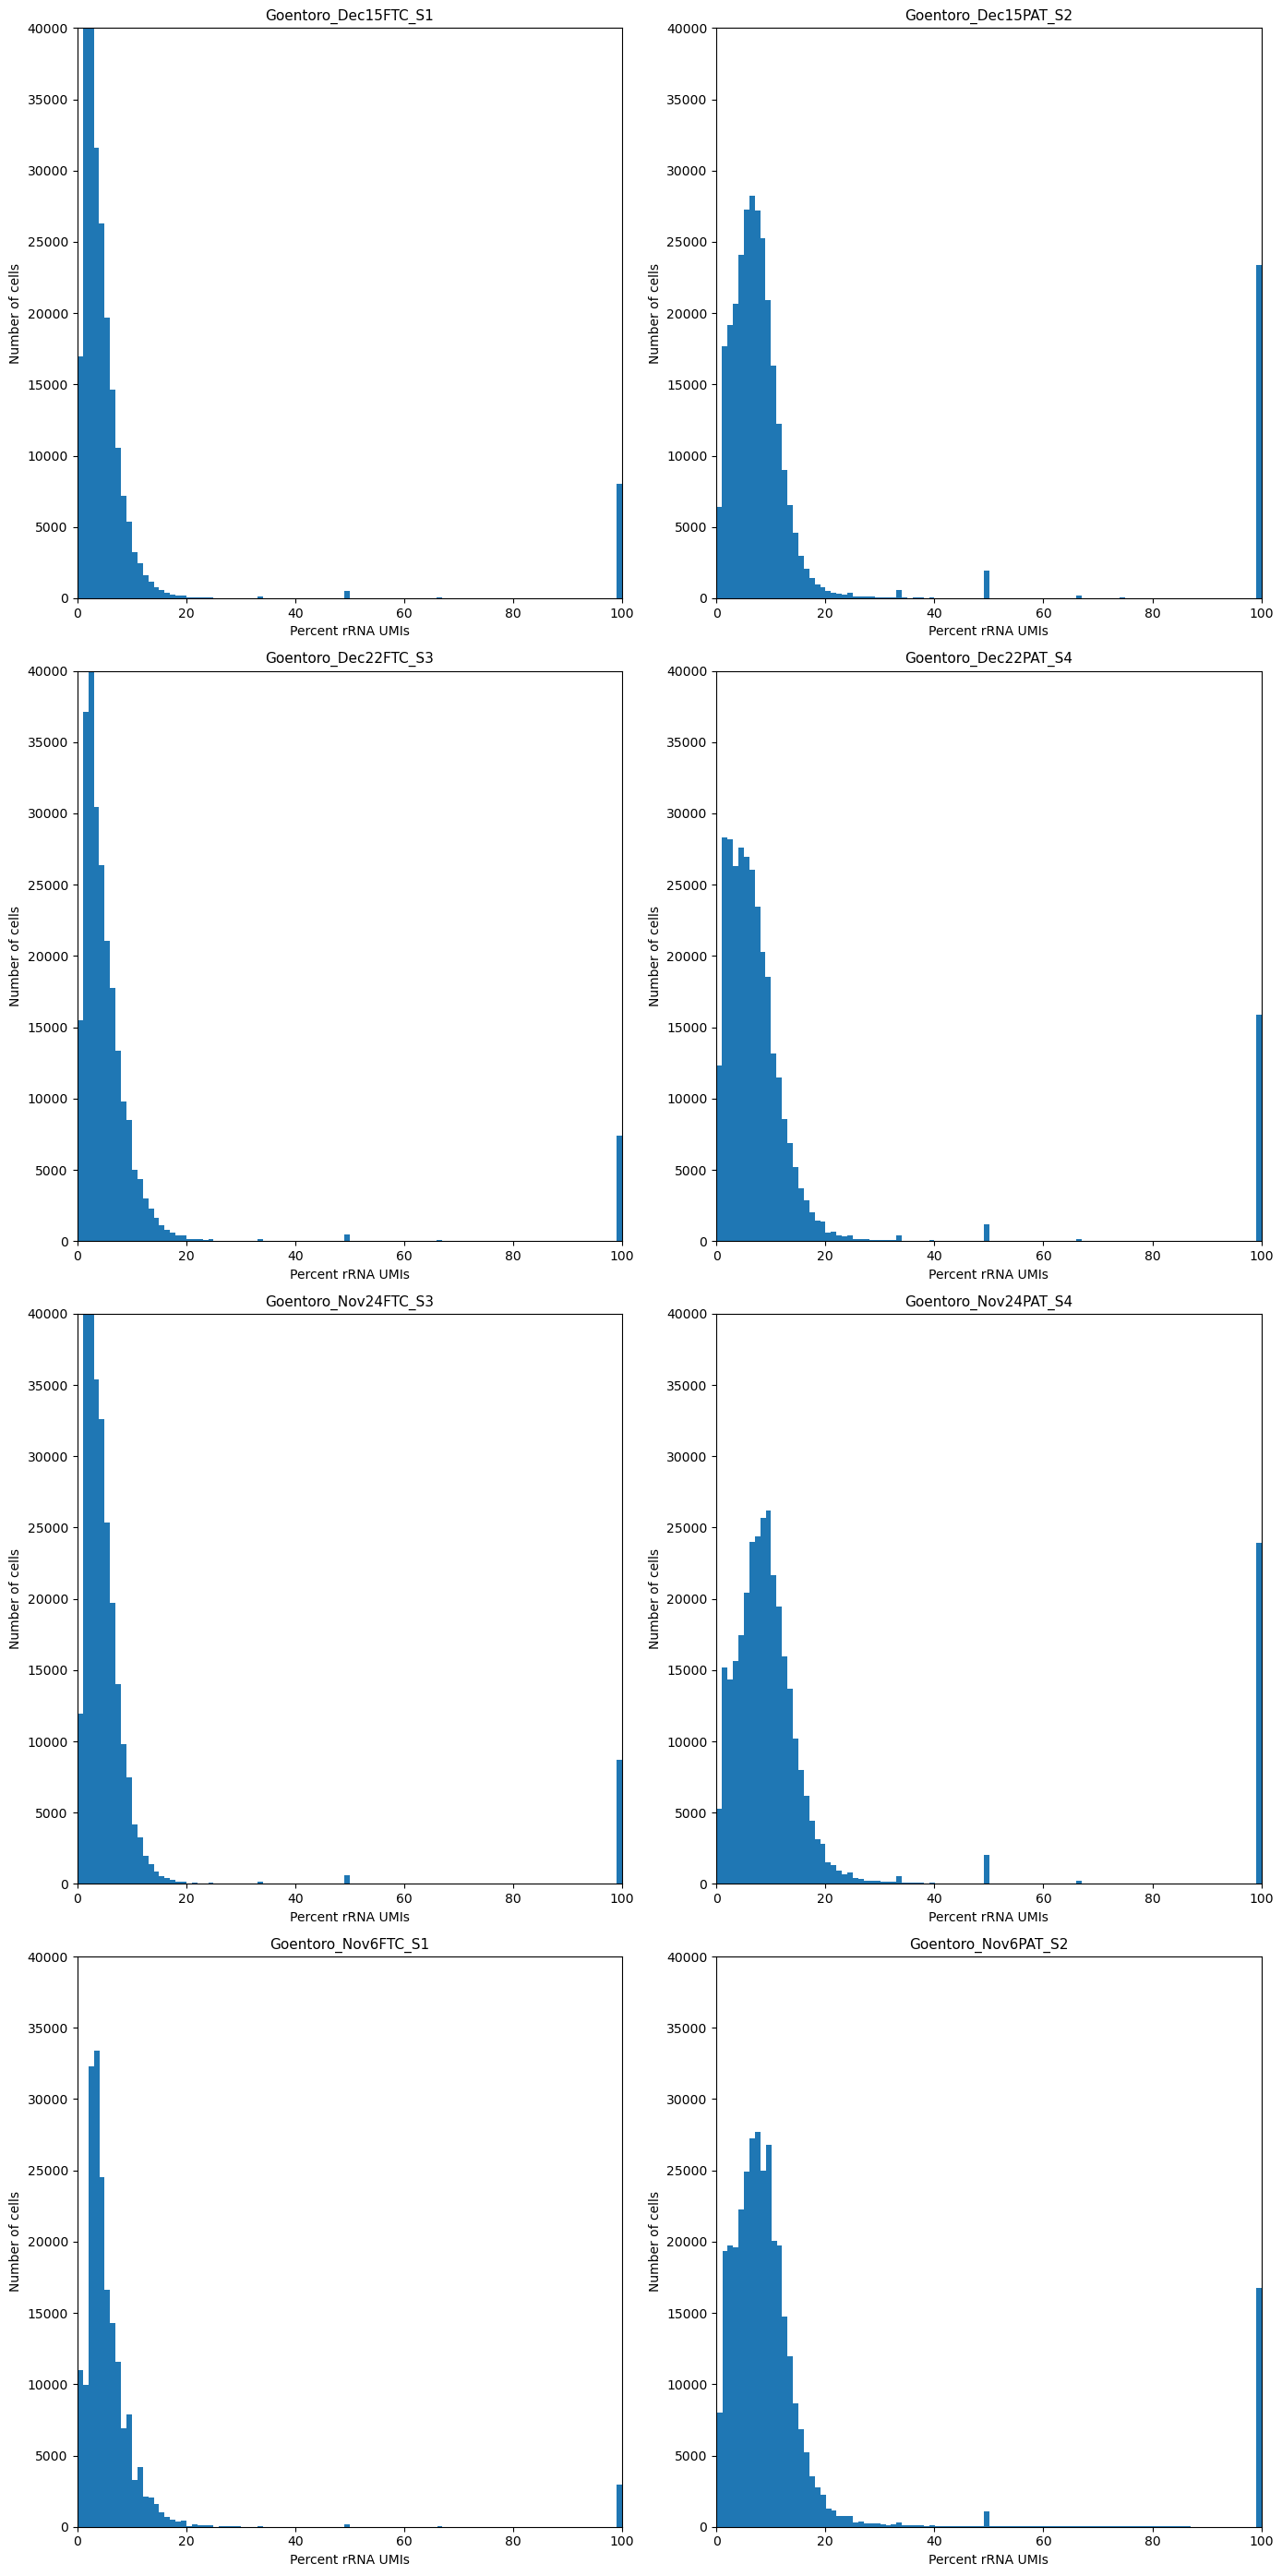

In [29]:
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]
    x = a.obs["percent_rrna"].to_numpy()
    x_plot = x[x > 0]   # exclude zeros for visualization only

    ax.hist(x_plot, bins=100)

    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_xlim(0, 100)   # adjust upper bound as needed
    ax.set_ylim(0, 40000)   # adjust upper bound as needed
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Percent rRNA UMIs")
    ax.set_ylabel("Number of cells")

plt.tight_layout()
plt.show()

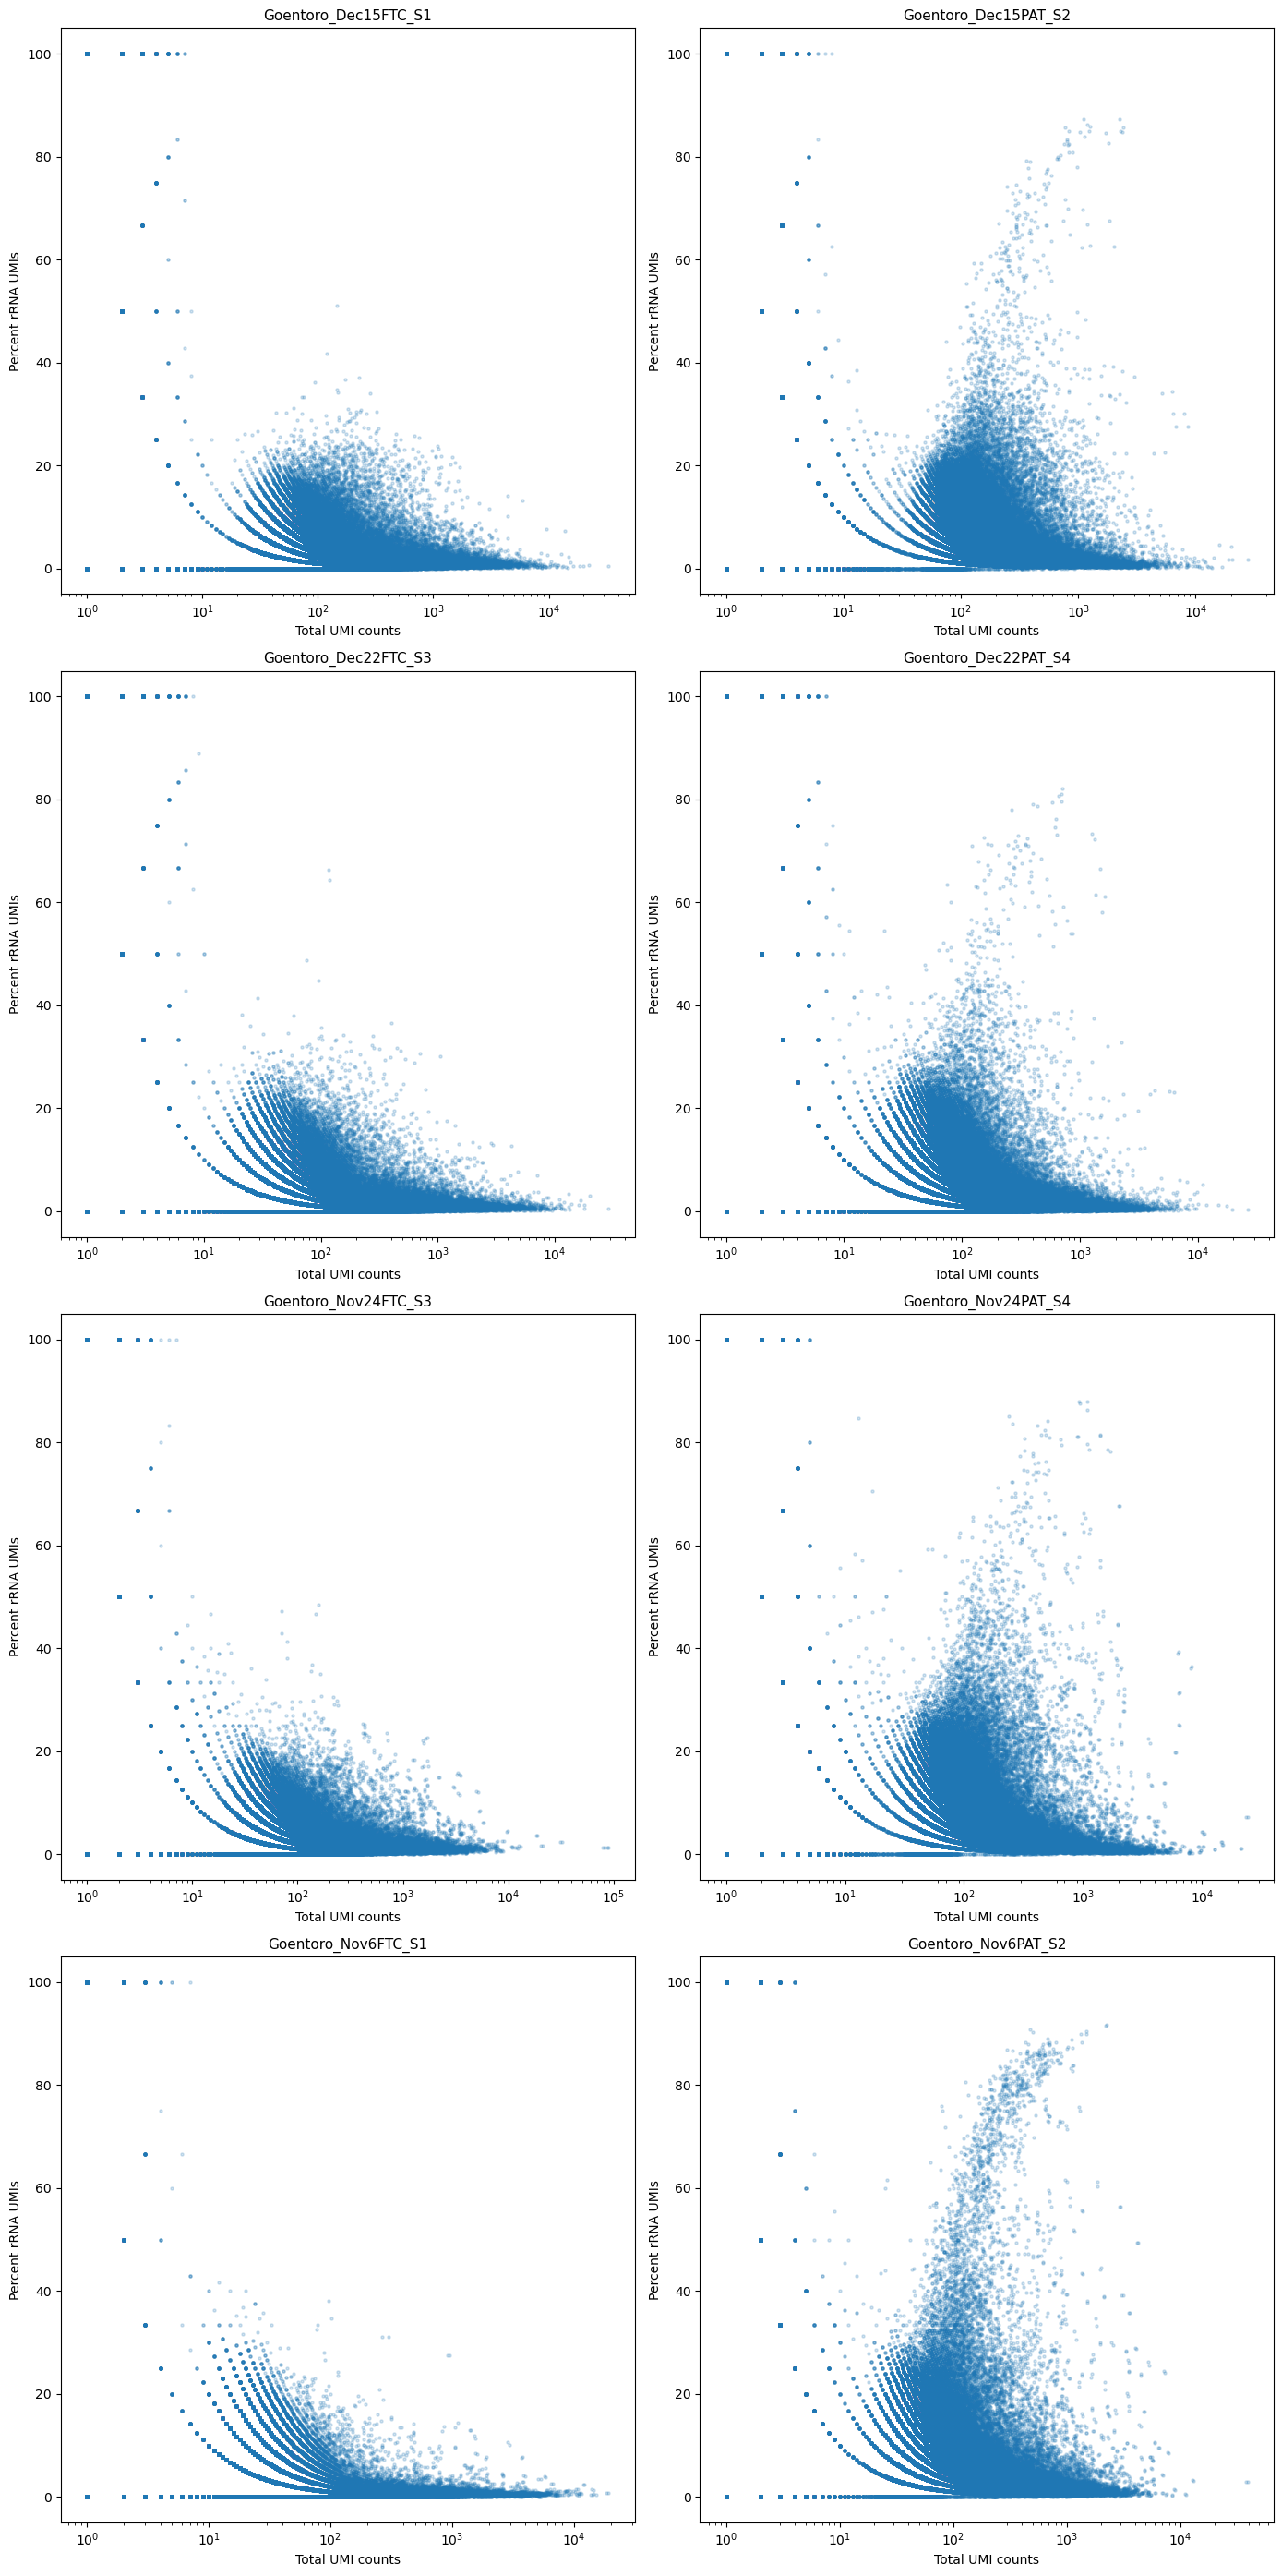

In [30]:
fig, axes = plt.subplots(4, 2, figsize=(14, 28))
axes = axes.flatten()

names = list(adatas.keys())

for ax, name in zip(axes, names):
    a = adatas[name]

    x = a.obs["total_counts"]
    y = a.obs["percent_rrna"]

    ax.scatter(x, y, s=5, alpha=0.2)
    ax.set_xscale("log")

    title = name.replace("_counts_unfiltered_merged", "")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Total UMI counts")
    ax.set_ylabel("Percent rRNA UMIs")

plt.tight_layout()
plt.show()

In [32]:
print("QC thresholds:")
print(f"  total_counts > {cutoff_umi}")
print(f"  n_genes_by_counts > {cutoff_gene}")
print(f"  percent_mito < {cutoff_mito}")
print(f"  min genes per cell is 3 (default in next code block)")

QC thresholds:
  total_counts > 200
  n_genes_by_counts > 200
  percent_mito < 15
  min genes per cell is 3 (default in next code block)
